# Linear Regression — Single Feature, From Scratch
6 buildings. 1 feature (sqft). Find the best line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

sqft = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui  = np.array([50, 55, 65, 70, 80, 85], dtype=float)

print("Our data:")
for s, e in zip(sqft, eui):
    print(f"  sqft={s:.0f}, EUI={e:.0f}")

Our data:
  sqft=10, EUI=50
  sqft=20, EUI=55
  sqft=30, EUI=65
  sqft=40, EUI=70
  sqft=50, EUI=80
  sqft=60, EUI=85


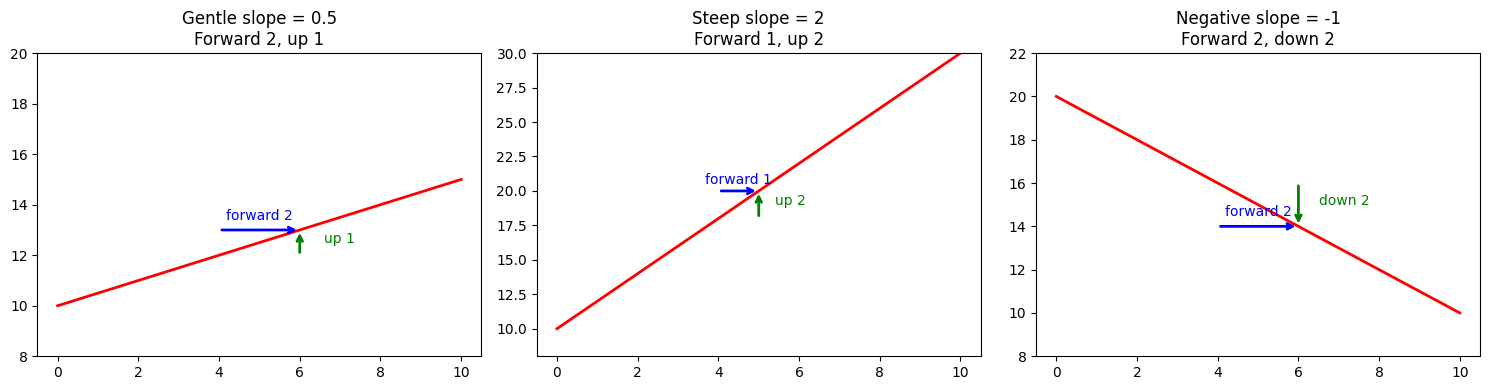

Slope = how much the line goes UP for every step FORWARD
  slope 0.5 = gentle uphill
  slope 2   = steep uphill
  slope -1  = going downhill


In [2]:
# What is a slope?
# A slope is just: how steep is the line?
# Walk along a road. For every step FORWARD, how much do you go UP?

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(0, 10, 100)

# Gentle slope: go forward 1, go up 0.5
axes[0].plot(x, 0.5 * x + 10, color='red', linewidth=2)
axes[0].annotate('', xy=(6, 13), xytext=(4, 13), arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[0].annotate('', xy=(6, 13), xytext=(6, 12), arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[0].text(5, 13.4, 'forward 2', ha='center', color='blue')
axes[0].text(6.6, 12.5, 'up 1', color='green')
axes[0].set_title('Gentle slope = 0.5\nForward 2, up 1')
axes[0].set_ylim(8, 20)

# Steep slope: go forward 1, go up 2
axes[1].plot(x, 2 * x + 10, color='red', linewidth=2)
axes[1].annotate('', xy=(5, 20), xytext=(4, 20), arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[1].annotate('', xy=(5, 20), xytext=(5, 18), arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[1].text(4.5, 20.5, 'forward 1', ha='center', color='blue')
axes[1].text(5.4, 19, 'up 2', color='green')
axes[1].set_title('Steep slope = 2\nForward 1, up 2')
axes[1].set_ylim(8, 30)

# Negative slope: go forward 1, go DOWN
axes[2].plot(x, -1 * x + 20, color='red', linewidth=2)
axes[2].annotate('', xy=(6, 14), xytext=(4, 14), arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[2].annotate('', xy=(6, 14), xytext=(6, 16), arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[2].text(5, 14.5, 'forward 2', ha='center', color='blue')
axes[2].text(6.5, 15, 'down 2', color='green')
axes[2].set_title('Negative slope = -1\nForward 2, down 2')
axes[2].set_ylim(8, 22)

plt.tight_layout()
plt.show()

print("Slope = how much the line goes UP for every step FORWARD")
print("  slope 0.5 = gentle uphill")
print("  slope 2   = steep uphill")
print("  slope -1  = going downhill")

Slope between each pair of neighbors:

  Building 1 -> 2:  EUI went up 5, sqft went up 10  ->  slope = 0.5
  Building 2 -> 3:  EUI went up 10, sqft went up 10  ->  slope = 1.0
  Building 3 -> 4:  EUI went up 5, sqft went up 10  ->  slope = 0.5
  Building 4 -> 5:  EUI went up 10, sqft went up 10  ->  slope = 1.0
  Building 5 -> 6:  EUI went up 5, sqft went up 10  ->  slope = 0.5

Different pairs give different slopes (0.5 and 1.0)
We need ONE slope that best fits ALL 6 points.

The trick: measure every point's rise and run from the CENTER (the averages)


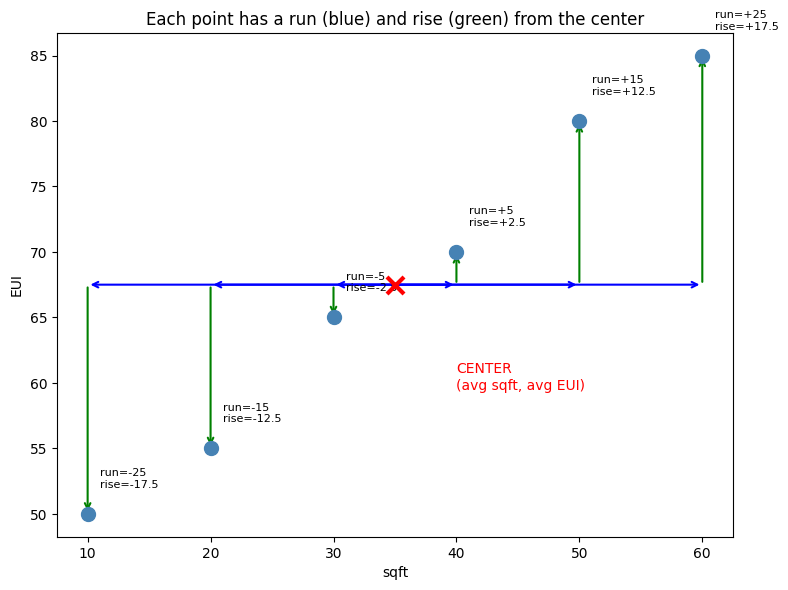

Blue arrows = run (how far left/right from center)
Green arrows = rise (how far up/down from center)


In [5]:
# Finding the best slope for 6 points — visually

# With 2 points, slope is simple: rise / run
# But with 6 points that don't line up perfectly, different pairs give different slopes:

print("Slope between each pair of neighbors:")
print()
for i in range(len(sqft) - 1):
    rise = eui[i+1] - eui[i]
    run = sqft[i+1] - sqft[i]
    slope = rise / run
    print(f"  Building {i+1} -> {i+2}:  EUI went up {rise:.0f}, sqft went up {run:.0f}  ->  slope = {slope:.1f}")

print()
print("Different pairs give different slopes (0.5 and 1.0)")
print("We need ONE slope that best fits ALL 6 points.")
print()
print("The trick: measure every point's rise and run from the CENTER (the averages)")

# Compute the center
avg_sqft = sqft.mean()
avg_eui = eui.mean()

# Plot showing rise/run from center for each point
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft, avg_eui, color='red', s=150, marker='x', zorder=5, linewidths=3)
ax.annotate('CENTER\n(avg sqft, avg EUI)', xy=(avg_sqft, avg_eui), xytext=(avg_sqft + 5, avg_eui - 8),
            fontsize=10, color='red')

# Draw arrows from center to each point
for i in range(len(sqft)):
    # Horizontal arrow (run)
    ax.annotate('', xy=(sqft[i], avg_eui), xytext=(avg_sqft, avg_eui),
                arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
    # Vertical arrow (rise)
    ax.annotate('', xy=(sqft[i], eui[i]), xytext=(sqft[i], avg_eui),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
    # Label
    run_val = sqft[i] - avg_sqft
    rise_val = eui[i] - avg_eui
    ax.text(sqft[i] + 1, eui[i] + 2, f'run={run_val:+.0f}\nrise={rise_val:+.1f}', fontsize=8)

ax.set_xlabel('sqft')
ax.set_ylabel('EUI')
ax.set_title('Each point has a run (blue) and rise (green) from the center')
plt.tight_layout()
plt.show()

print("Blue arrows = run (how far left/right from center)")
print("Green arrows = rise (how far up/down from center)")

In [ ]:
# Now let's combine all 6 rise/run pairs into ONE slope
# 
# We can't just add rises and divide by sum of runs — negatives would cancel out.
# So we do it in two parts:

sqft_diff = sqft - avg_sqft   # each building's "run" from center
eui_diff  = eui - avg_eui     # each building's "rise" from center

print("Part 1: Multiply each building's run x rise")
print("        (this keeps the sign — if both are negative, product is positive)")
print()
print("Building |  run   |  rise  | run x rise")
print("-" * 50)

products = sqft_diff * eui_diff
for i in range(len(sqft)):
    print(f"   {i+1}     | {sqft_diff[i]:+6.1f} | {eui_diff[i]:+6.1f} | {products[i]:+9.2f}")

top = products.sum()
print(f"\nSum of (run x rise) = {top:.1f}")
print("This is the TOTAL RISE CONTRIBUTION across all buildings.")

print("\n" + "=" * 50)
print()
print("Part 2: Square each building's run")
print("        (measures total horizontal spread)")
print()
print("Building |  run   | run squared")
print("-" * 35)

sqft_sq = sqft_diff ** 2
for i in range(len(sqft)):
    print(f"   {i+1}     | {sqft_diff[i]:+6.1f} | {sqft_sq[i]:7.1f}")

bottom = sqft_sq.sum()
print(f"\nSum of run squared = {bottom:.1f}")
print("This is the TOTAL RUN.")

print("\n" + "=" * 50)
print()
slope = top / bottom
print(f"Best slope = total rise contribution / total run")
print(f"           = {top:.1f} / {bottom:.1f}")
print(f"           = {slope:.4f}")
print()
print(f"For every 1 sqft increase, EUI goes up by {slope:.4f}")
print()
print("It's still rise / run — just computed across all 6 points at once.")

In [ ]:
# Step 1: Averages
avg_sqft = sqft.mean()
avg_eui = eui.mean()

print(f"Average sqft: {avg_sqft}")
print(f"Average EUI:  {avg_eui}")

In [ ]:
# Step 2: How far is each building from the average?
sqft_diff = sqft - avg_sqft
eui_diff = eui - avg_eui

print("Building | sqft | sqft_diff | EUI | eui_diff")
print("-" * 50)
for i in range(len(sqft)):
    print(f"   {i+1}     | {sqft[i]:4.0f} |  {sqft_diff[i]:+6.1f}  | {eui[i]:4.0f} | {eui_diff[i]:+6.1f}")

In [ ]:
# Step 3: Multiply the differences pair by pair
products = sqft_diff * eui_diff

print("Building | sqft_diff | eui_diff | product")
print("-" * 50)
for i in range(len(sqft)):
    print(f"   {i+1}     |  {sqft_diff[i]:+6.1f}  | {eui_diff[i]:+6.1f}  | {products[i]:+8.2f}")

print(f"\nSum of products: {products.sum():.1f}")
print("All positive — sqft and EUI move in the same direction.")

In [ ]:
# Step 4: Square the sqft differences
sqft_diff_squared = sqft_diff ** 2

print("Building | sqft_diff | squared")
print("-" * 35)
for i in range(len(sqft)):
    print(f"   {i+1}     |  {sqft_diff[i]:+6.1f}  | {sqft_diff_squared[i]:.1f}")

print(f"\nSum of squares: {sqft_diff_squared.sum():.1f}")
print("This measures how spread out the sqft values are.")

In [ ]:
# Step 5: The slope (w) = sum of products / sum of squares
w = products.sum() / sqft_diff_squared.sum()

print(f"Slope (w) = {products.sum():.1f} / {sqft_diff_squared.sum():.1f} = {w:.4f}")
print(f"\nMeaning: for every 1 sqft increase, EUI goes up by {w:.4f}")

In [ ]:
# Step 6: The intercept (b)
# The line must pass through (avg_sqft, avg_eui)
# So: avg_eui = w * avg_sqft + b
# Therefore: b = avg_eui - w * avg_sqft

b = avg_eui - w * avg_sqft

print(f"Intercept (b) = {avg_eui} - {w:.4f} * {avg_sqft} = {b:.2f}")
print(f"\nOur line: prediction = {w:.4f} * sqft + {b:.2f}")

In [ ]:
# Let's see how good our line is
predictions = w * sqft + b
errors = eui - predictions
squared_errors = errors ** 2

print("Building | Actual EUI | Predicted | Error | Squared Error")
print("-" * 62)
for i in range(len(sqft)):
    print(f"   {i+1}     |   {eui[i]:5.1f}    |  {predictions[i]:5.1f}   | {errors[i]:+5.1f} |   {squared_errors[i]:.2f}")

print(f"\nTotal squared error: {squared_errors.sum():.2f}")
print("No other line can get a lower number than this.")

In [ ]:
# Prove it — try some other lines and compare
print("Trying random lines:\n")
for test_w, test_b in [(1.0, 40), (0.5, 50), (0.8, 42), (0.6, 47)]:
    test_pred = test_w * sqft + test_b
    test_error = ((eui - test_pred) ** 2).sum()
    print(f"  w={test_w}, b={test_b}  -> total squared error: {test_error:.2f}")

print(f"\n  w={w:.4f}, b={b:.2f}  -> total squared error: {squared_errors.sum():.2f}  <-- OUR LINE (lowest)")

In [ ]:
# Visualize it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: our best fit line
x_line = np.linspace(0, 70, 100)
axes[0].scatter(sqft, eui, color='steelblue', s=80, zorder=5)
axes[0].plot(x_line, w * x_line + b, color='red', linewidth=2)
# Draw error lines from each point to the line
for i in range(len(sqft)):
    axes[0].plot([sqft[i], sqft[i]], [eui[i], predictions[i]], color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'Best fit line (total error: {squared_errors.sum():.1f})')
axes[0].set_xlabel('sqft')
axes[0].set_ylabel('EUI')

# Right: a bad line for comparison
bad_w, bad_b = 1.0, 40
bad_pred = bad_w * sqft + bad_b
bad_error = ((eui - bad_pred) ** 2).sum()
axes[1].scatter(sqft, eui, color='steelblue', s=80, zorder=5)
axes[1].plot(x_line, bad_w * x_line + bad_b, color='red', linewidth=2)
for i in range(len(sqft)):
    axes[1].plot([sqft[i], sqft[i]], [eui[i], bad_pred[i]], color='gray', linestyle='--', linewidth=1)
axes[1].set_title(f'Random line w=1, b=40 (total error: {bad_error:.1f})')
axes[1].set_xlabel('sqft')
axes[1].set_ylabel('EUI')

plt.tight_layout()
plt.show()
print("Gray dashed lines = errors. Shorter lines = better fit.")